In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [26]:
avg_income = np.mean(df['MonthlyIncome'])
std_income = np.std(df['MonthlyIncome'])
print("Average Income:", avg_income)
print("Std Dev:", std_income)

Average Income: 6502.931292517007
Std Dev: 4706.355164823003


In [16]:
print(df.info())
print(df['Attrition'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [17]:
# Convert Attrition to numeric
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [18]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [19]:
attrition_rate = df['Attrition'].mean() * 100
print("Attrition Rate:", attrition_rate)

Attrition Rate: 16.122448979591837


In [20]:
dept_attrition = df.groupby('Department')['Attrition'].mean() * 100
print(dept_attrition)

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition, dtype: float64


In [21]:
df['Age_Group'] = np.where(df['Age'] < 30, 'Young',
                   np.where(df['Age'] < 45, 'Mid', 'Senior'))

age_attrition = df.groupby('Age_Group')['Attrition'].mean() * 100
print(age_attrition)

Age_Group
Mid       13.253012
Senior    11.464968
Young     27.914110
Name: Attrition, dtype: float64


In [22]:
salary_attrition = df.groupby('MonthlyIncome')['Attrition'].mean()
print(salary_attrition.head())

MonthlyIncome
1009    1.0
1051    0.0
1052    0.0
1081    1.0
1091    1.0
Name: Attrition, dtype: float64


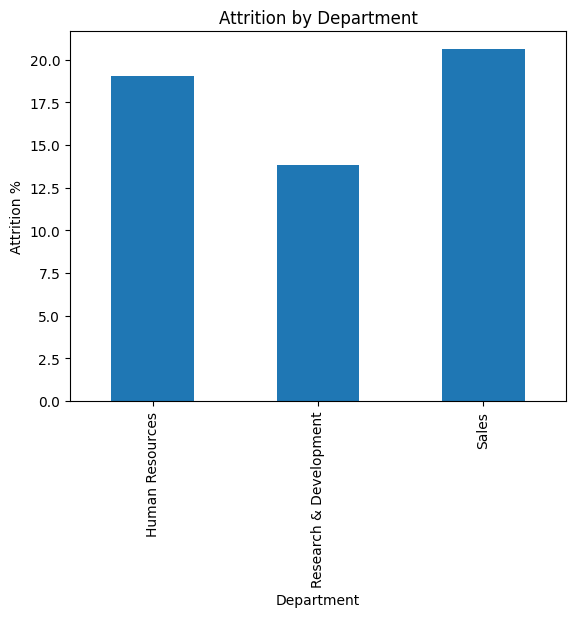

In [23]:
dept_attrition.plot(kind='bar', title='Attrition by Department')
plt.ylabel('Attrition %')
plt.show()

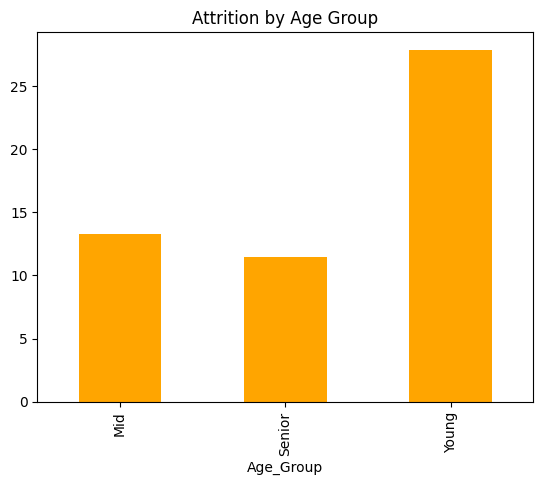

In [24]:
age_attrition.plot(kind='bar', color='orange', title='Attrition by Age Group')
plt.show()

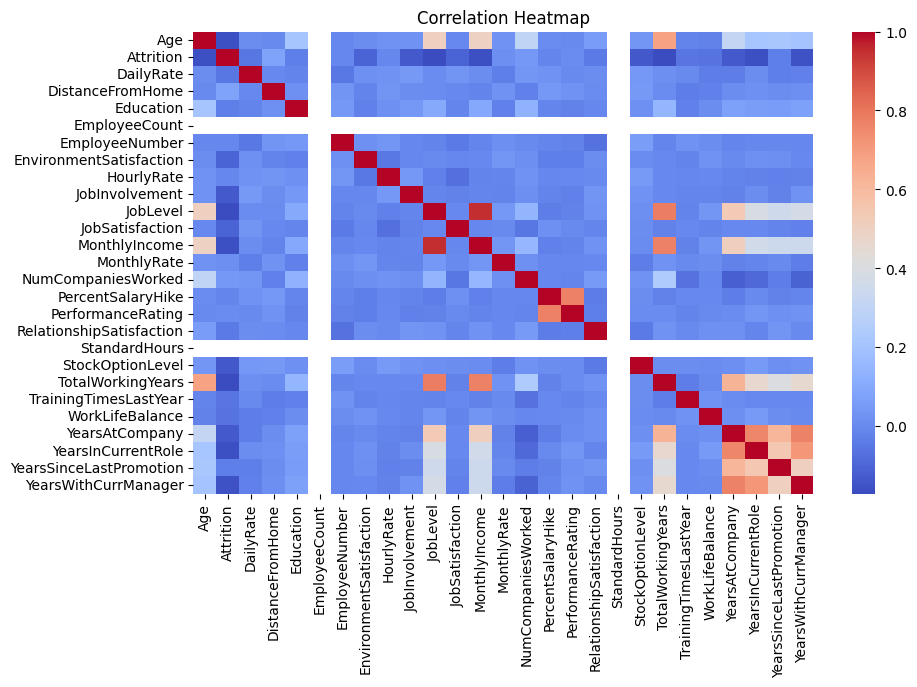

In [25]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()